In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# add utils folder to path
# add path to the directory containing the module
cwd = os.getcwd()
# parent directory
parent = os.path.dirname(cwd)
import sys
sys.path.append(parent)
from utils.data import load_sc_data
from utils import data

device = torch.device('cuda')
idb = 4
db = data.dbs[idb]

# load data

In [25]:
img_downsample = 1
data_path = f'../data/sc_processed_data_{db["mname"]}_{db["datexp"]}.npz'
if idb == 4:
    data_path = f'../data/sc_processed_data_all.npz'
img_train, img_val, img_test, spks_train, spks_val, spks_test_rep, fev_all = load_sc_data(img_downsample = img_downsample,
                 use_sensorium_normalization = True,
                 use_zscore_normalization = False,
                 data_path = data_path)

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test_rep.shape, spks_test_rep.min(), spks_test_rep.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

(1600,) (400,)
(1600, 66, 77) (400, 66, 77) (500, 66, 77)
(140, 1600) (140, 400) (2, 140, 500)
(140,)
downsample images:
train images: (1600, 66, 77)
val images: (400, 66, 77)
test images: (500, 66, 77)
spks_train:  (140, 1600) nan nan
spks_val:  (140, 400) nan nan
spks_test:  (2, 140, 500) nan nan
img_train:  (1600, 66, 77) -2.089102 2.061593
img_val:  (400, 66, 77) -2.089102 2.061593
img_test:  (500, 66, 77) -2.089102 2.061593


In [26]:
fev_threshold = -1
ineur = np.where(fev_all > fev_threshold)[0]
print(f'selecting {len(ineur)} neurons with fev > {fev_threshold}') 

spks_train = torch.from_numpy(spks_train[ineur].T)
spks_val = torch.from_numpy(spks_val[ineur].T)
spks_test_rep = torch.from_numpy(spks_test_rep[:, ineur])    
spks_test = spks_test_rep[0].T

print(spks_train.shape, spks_val.shape, spks_test.shape)

img_train = torch.from_numpy(img_train).to(device).unsqueeze(1)
img_val = torch.from_numpy(img_val).to(device).unsqueeze(1)
img_test = torch.from_numpy(img_test).to(device).unsqueeze(1)

print(img_train.shape, img_val.shape, img_test.shape)

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test.shape, spks_test.min(), spks_test.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

input_Ly, input_Lx = img_train.shape[-2:]

# spks_train:  torch.Size([1020, 107]) tensor(-0.6189) tensor(19.5009)
# spks_val:  torch.Size([254, 107]) tensor(-0.6189) tensor(22.7685)
# spks_test:  torch.Size([136, 107]) tensor(-0.6189) tensor(18.0390)
# img_train:  torch.Size([1020, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
# img_val:  torch.Size([254, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
# img_test:  torch.Size([136, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)

Nrep, NN, NT = spks_test_rep.shape
spks_rep_all = []
for i in range(NT):
    spks_rep_all.append(spks_test_rep[:, :, i].cpu().numpy())

selecting 140 neurons with fev > -1
torch.Size([1600, 140]) torch.Size([400, 140]) torch.Size([500, 140])
torch.Size([1600, 1, 66, 77]) torch.Size([400, 1, 66, 77]) torch.Size([500, 1, 66, 77])
spks_train:  torch.Size([1600, 140]) tensor(nan) tensor(nan)
spks_val:  torch.Size([400, 140]) tensor(nan) tensor(nan)
spks_test:  torch.Size([500, 140]) tensor(nan) tensor(nan)
img_train:  torch.Size([1600, 1, 66, 77]) tensor(-2.0891, device='cuda:0') tensor(2.0616, device='cuda:0')
img_val:  torch.Size([400, 1, 66, 77]) tensor(-2.0891, device='cuda:0') tensor(2.0616, device='cuda:0')
img_test:  torch.Size([500, 1, 66, 77]) tensor(-2.0891, device='cuda:0') tensor(2.0616, device='cuda:0')


In [27]:
# deal with the nan values
spks_train_real = np.ones(spks_train.shape)
spks_val_real = np.ones(spks_val.shape)
spks_test_real = np.ones(spks_test.shape)

spks_train_real[np.isnan(spks_train.cpu().numpy())] = 0
spks_val_real[np.isnan(spks_val.cpu().numpy())] = 0
spks_test_real[np.isnan(spks_test.cpu().numpy())] = 0

spks_train_real = torch.from_numpy(spks_train_real)
spks_val_real = torch.from_numpy(spks_val_real)
spks_test_real = torch.from_numpy(spks_test_real)

spks_train[torch.isnan(spks_train)] = 0
spks_val[torch.isnan(spks_val)] = 0
spks_test[torch.isnan(spks_test)] = 0

print(spks_train.shape, spks_train.min(), spks_train.max())
print(spks_val.shape, spks_val.min(), spks_val.max())
print(spks_test.shape, spks_test.min(), spks_test.max())

torch.Size([1600, 140]) tensor(0.) tensor(18.7531)
torch.Size([400, 140]) tensor(0.) tensor(11.3995)
torch.Size([500, 140]) tensor(0.) tensor(21.2155)


# build model

In [28]:
# build model
from minimodel import model_builder
nlayers = 2
nconv1 = 64
nconv2 = 64
conv1_ks = 9
conv2_ks = 7
pool = True
weight_path = '../weights/'
model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, input_Ly=66, input_Lx=77, kernel_size=[conv1_ks,conv2_ks], pool=pool, stride=2)
model_name = model_builder.create_model_name(f'SC_{db["mname"]}', db["datexp"], n_layers=nlayers, in_channels=in_channels, suffix=f'ks_{conv1_ks}_{conv2_ks}', pool=pool)

model_path = os.path.join(weight_path, model_name)
model = model.to(device)

core shape:  torch.Size([1, 64, 33, 38])
input shape of readout:  (64, 33, 38)
model name:  SC_all_data_2layer_64_64_clamp_norm_depthsep_pool_ks_9_7.pt


In [29]:
# train model
from minimodel import model_trainer
if not os.path.exists(model_path):
    best_state_dict = model_trainer.monkey_train(model, spks_train, spks_train_real, spks_val, spks_val_real, img_train, img_val, device=device, n_epochs_period=[50, 30, 30, 30], lr_init=0.01)
    torch.save(best_state_dict, model_path)
    print('saved model', model_path)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

loaded model ../weights/SC_all_data_2layer_64_64_clamp_norm_depthsep_pool_ks_9_7.pt


In [30]:
# test model
test_pred = model_trainer.test_epoch(model, img_test)
print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

from minimodel import metrics
test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)

threshold = 0.15
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

test_pred:  (500, 140) 0.06894863 2.3802347
filtering neurons with FEV > 0.15
valid neurons: 37 / 140
FEVE (test): 0.44090497493743896


/media/carsen/ssd1/minimodel/minimodel/metrics.py:72: RuntimeWarning: Degrees of freedom <= 0 for slice.
  noise_var.append(np.nanvar(spks[i], axis=0, ddof=1))


In [31]:
model

Encoder(
  (core): Core(
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4), bias=False)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer1): Sequential(
        (ds_conv): Sequential(
          (in_depth_conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (spatial_conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=64, bias=False)
          (out_depth_conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
      )
    )
  )
  (readout): Readout(
    (activation): ELU(alpha=1.0)
  )
  (bceloss): BCELoss(

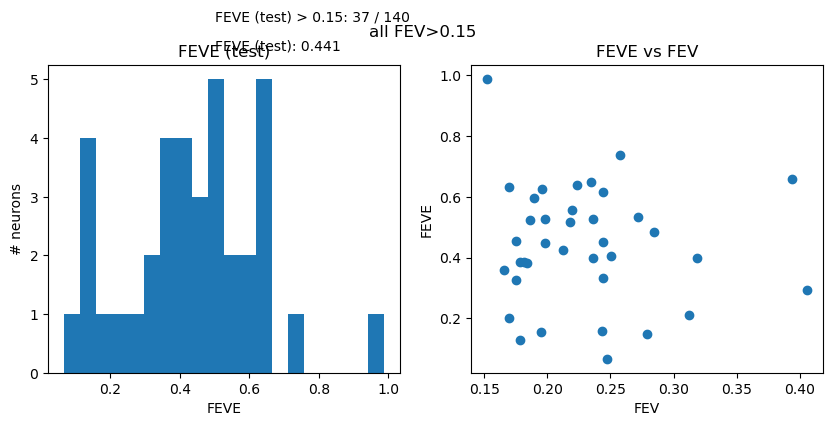

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
valid_idxes = np.where(test_fev > threshold)[0]
ax[0].hist(test_feve[valid_idxes], bins=20)
ax[0].set_title('FEVE (test)')
ax[0].set_xlabel('FEVE')
ax[0].set_ylabel('# neurons')
ax[0].text(0.5, 6, f'FEVE (test) > {threshold}: {len(valid_idxes)} / {len(test_feve)}')
ax[0].text(0.5, 5.5, f'FEVE (test): {np.mean(test_feve[test_fev > threshold]):.3f}')
ax[1].scatter(test_fev[valid_idxes], test_feve[valid_idxes])
ax[1].set_title('FEVE vs FEV')
ax[1].set_xlabel('FEV')
ax[1].set_ylabel('FEVE')
plt.suptitle(f'{db["mname"]} FEV>{threshold}')
plt.show()

(64, 1, 9, 9)


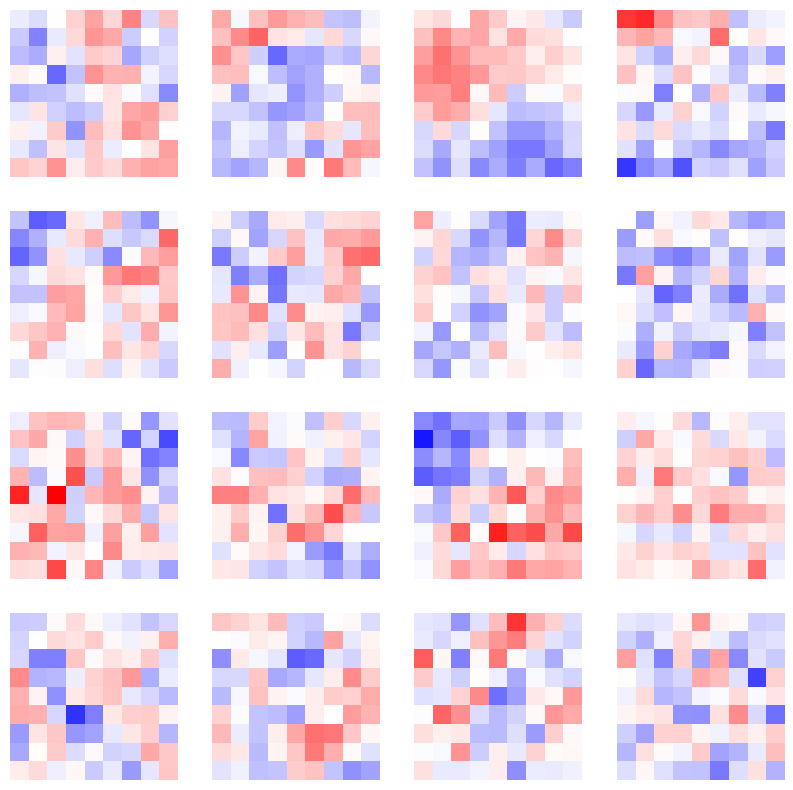

In [33]:
conv1 = model.core.features.layer0.conv.weight.cpu().detach().numpy()
print(conv1.shape)
import cv2
# plot filters
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i in range(16):
    im = conv1[i, 0]
    # gaussian filter
    # im = cv2.GaussianBlur(im, (3, 3), 0)
    ax[i//4, i%4].imshow(im, cmap='bwr', vmin=-0.1, vmax=0.1)
    ax[i//4, i%4].axis('off')

# LN model

In [42]:
# build model
from minimodel import model_builder
nlayers = 2
nconv1 = 16
nconv2 = 64
conv1_ks = 9
conv2_ks = 7
weight_path = '../weights/'
model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, input_Ly=66, input_Lx=77, activation=None, pool=True, kernel_size=[conv1_ks,conv2_ks])
model_name = model_builder.create_model_name(f'SC_{db["mname"]}', db["datexp"], n_layers=nlayers, in_channels=in_channels, suffix='LN_pool', pool=True)

model_path = os.path.join(weight_path, model_name)
model = model.to(device)

core shape:  torch.Size([1, 64, 33, 38])
input shape of readout:  (64, 33, 38)
model name:  SC_all_data_2layer_16_64_clamp_norm_depthsep_pool_LN_pool.pt


In [43]:
# train model
# from minimodel import model_trainer
# if not os.path.exists(model_path):
#     best_state_dict = model_trainer.train(model, spks_train, spks_val, img_train, img_val, device=device, n_epochs_period=[30, 30, 30, 30])
#     torch.save(best_state_dict, model_path)
#     print('saved model', model_path)
# model.load_state_dict(torch.load(model_path))
# print('loaded model', model_path)

from minimodel import model_trainer
if not os.path.exists(model_path):
    best_state_dict = model_trainer.monkey_train(model, spks_train, spks_train_real, spks_val, spks_val_real, img_train, img_val, device=device, n_epochs_period=[100, 30, 30, 30], lr_init=0.0003)
    torch.save(best_state_dict, model_path)
    print('saved model', model_path)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

0.0003
epoch 0, train_loss = 0.0100, val_loss = 0.0100, varexp_val = -0.1851, time 0.14s
epoch 5, train_loss = 0.0094, val_loss = 0.0092, varexp_val = -0.0389, time 0.79s
epoch 10, train_loss = 0.0090, val_loss = 0.0089, varexp_val = 0.0167, time 1.43s
epoch 15, train_loss = 0.0090, val_loss = 0.0089, varexp_val = 0.0172, time 2.06s
epoch 20, train_loss = 0.0089, val_loss = 0.0089, varexp_val = 0.0183, time 2.75s
epoch 25, train_loss = 0.0089, val_loss = 0.0089, varexp_val = 0.0192, time 3.41s
epoch 30, train_loss = 0.0089, val_loss = 0.0089, varexp_val = 0.0174, time 4.06s
epoch 35, train_loss = 0.0089, val_loss = 0.0089, varexp_val = 0.0150, time 4.68s
epoch 40, train_loss = 0.0088, val_loss = 0.0089, varexp_val = 0.0166, time 5.32s
epoch 45, train_loss = 0.0088, val_loss = 0.0090, varexp_val = 0.0118, time 5.97s
epoch 50, train_loss = 0.0088, val_loss = 0.0090, varexp_val = 0.0122, time 6.65s
epoch 55, train_loss = 0.0088, val_loss = 0.0090, varexp_val = 0.0102, time 7.35s
epoch 60,

In [44]:
# test model
test_pred = model_trainer.test_epoch(model, img_test)
print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

from minimodel import metrics
test_fev, test_feve = metrics.feve_nan(spks_rep_all, test_pred)

threshold = 0.15
print(f'filtering neurons with FEV > {threshold}')
valid_idxes = np.where(test_fev > threshold)[0]
print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')

test_pred:  (500, 140) 0.13684535 2.4653008
filtering neurons with FEV > 0.15
valid neurons: 37 / 140
FEVE (test): 0.25797075033187866


/media/carsen/ssd1/minimodel/minimodel/metrics.py:72: RuntimeWarning: Degrees of freedom <= 0 for slice.
  noise_var.append(np.nanvar(spks[i], axis=0, ddof=1))


# multilayer result

In [45]:
# build model
from minimodel import model_builder
nlayers = 1
nconv1 = 64
nconv2 = 64
weight_path = '../weights/'
fev_nlayers = []
for nlayers in range(1, 5):
    model, in_channels = model_builder.build_model(NN=len(ineur), n_layers=nlayers, n_conv=nconv1, n_conv_mid=nconv2, input_Ly=66, input_Lx=77, pool=False)
    model_name = model_builder.create_model_name(f'SC_{db["mname"]}', db["datexp"], n_layers=nlayers, in_channels=in_channels)#, suffix='tmp')

    model_path = os.path.join(weight_path, model_name)
    model = model.to(device)

    # train model
    from minimodel import model_trainer
    model.load_state_dict(torch.load(model_path))
    print('loaded model', model_path)

    # test model
    test_pred = model_trainer.test_epoch(model, img_test)
    print('test_pred: ', test_pred.shape, test_pred.min(), test_pred.max())

    from minimodel import metrics
    test_fev, test_feve = metrics.feve(spks_rep_all, test_pred)

    threshold = 0.15
    print(f'filtering neurons with FEV > {threshold}')
    valid_idxes = np.where(test_fev > threshold)[0]
    print(f'valid neurons: {len(valid_idxes)} / {len(test_fev)}')
    print(f'FEVE (test): {np.mean(test_feve[test_fev > threshold])}')
    fev_nlayers.append(test_feve[valid_idxes])

core shape:  torch.Size([1, 64, 33, 39])
input shape of readout:  (64, 33, 39)
model name:  SC_all_data_1layer_64_clamp_norm_depthsep_pool.pt


FileNotFoundError: [Errno 2] No such file or directory: '../weights/SC_all_data_1layer_64_clamp_norm_depthsep_pool.pt'

Text(3.0, 0.12, 'LN baseline')

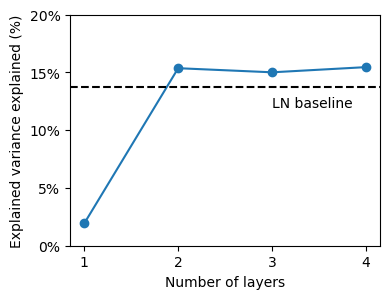

In [ ]:
LN_result = 0.1371200978755951

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.plot(np.arange(1, 5), [np.mean(fev) for fev in fev_nlayers], 'o-')
ax.axhline(LN_result, color='k', linestyle='--')
ax.set_xlabel('Number of layers')
ax.set_ylabel('Explained variance explained (%)')
ax.set_ylim(0, 0.2)
# ax.set_yticks(np.arange(0, 0.21, 0.05), ticklabels=[f'{x*100:.0f}%' for x in np.arange(0, 0.21, 0.05)])
# set y ticks
yticks = np.arange(0, 0.21, 0.05)
yticklabels = [f'{x*100:.0f}%' for x in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_xticks(np.arange(1, 5))
ax.text(3., 0.12, f'LN baseline')

In [ ]:
from approxineuro import datasets
use_sensorium_normalization = True
gabor = False
depth_separable = True
pool = True
highres = True
highvar = False
clamp = True
multikernel = False
multikernel_sizes = [9,25,49]
orth_reg = 0
use_30k = False # use all training data (>30k) or only 30k, performance will decrease.

img_downsample = 1 if highres else 2

In [ ]:
nlayers = 2
nconv1 = 16
nconv2 = 120
l1_readout = 0
model, in_channels = build_model(nlayers, nconv1, nconv2, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes, 
                    depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization)

# weight_path = '/home/carsen/dm11/Farah/EncodingModel'
weight_path = '../weights/old/'
model_path = create_model_name(weight_path, in_channels, fev_threshold, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes,
                                depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization, gabor=gabor,
                                rank=1, orth_reg=orth_reg, highvar=highvar, use_30k=use_30k, l1_readout=l1_readout)
print(model_path)

input shape of readout:  (120, 33, 38)
../weights/old/sc_2layer_fev-1_16_120_clamp_sensorium_depthsep_pool.pt


In [ ]:
model

Encoder(
  (core): Core(
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(1, 16, kernel_size=(25, 25), stride=(1, 1), padding=(12, 12), bias=False)
        (norm): BatchNorm2d(16, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
        (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (layer1): Sequential(
        (ds_conv): Sequential(
          (in_depth_conv): Conv2d(16, 120, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (spatial_conv): Conv2d(120, 120, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4), groups=120, bias=False)
          (out_depth_conv): Conv2d(120, 120, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (norm): BatchNorm2d(120, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
        (activation): ELU(alpha=1.0)
      )
    )
  )
  (readout): Readout(
    (activation): ELU(alpha=1.0)
  )
  (bceloss

# train

In [ ]:
if not os.path.exists(model_path):
    import time
    batch_size = 64
    detach_core = False

    n_periods = 4

    for i_period in range(n_periods):
        lr = 1e-3 / (3 ** (i_period))
        print(lr)

        restore = (i_period > 0)
        if restore:
            model.load_state_dict(best_state_dict)
        else:
            varexp_max = -100

        tic = time.time()
        
        n_epochs = 50 if i_period == 0 else 10

        optimizer = torch.optim.AdamW([{'params': model.core.parameters(), 'weight_decay': 0.1},
                                    {'params': [model.readout.Wc, model.readout.Wy, model.readout.Wx], 
                                        'weight_decay': 1.0},
                                    {'params': model.readout.bias, 'weight_decay': 0}
                                    ], lr=lr)

        for epoch in range(n_epochs):
            model.train()
            train_loss, lmax = encoder.train_epoch(model, optimizer, 
                                                        img_train, spks_train, 
                                                        epoch=epoch, batch_size=batch_size,
                                                        l1_readout=l1_readout,
                                                        device=device, detach_core=detach_core, clamp=clamp, orth_reg=orth_reg)
            model.eval()
            val_loss, varexp, cc, test_vmax, _ = encoder.test_epoch(model, img_val, spks_val, 
                                                                        batch_size=batch_size, 
                                                                        l1_readout=l1_readout,
                                                                        device=device)
            if varexp.mean() > varexp_max:
                best_state_dict = encoder.copy_state(model)
                varexp_max = varexp.mean()

            if epoch==0:
                print(lmax)

            if epoch%5==0 or epoch+1==n_epochs:
                test_loss, varexp_test, cc, test_vmax, _ = encoder.test_epoch(model, img_test, spks_test, 
                                                                        batch_size=batch_size, 
                                                                        l1_readout=l1_readout,
                                                                        device=device)
                print(f'epoch {epoch}, train_loss = {train_loss:0.4f}, varexp_val = {varexp.mean():0.4f}, varexp_test = {varexp_test.mean():0.4f}, cc = {cc.mean():0.4f}, time {time.time()-tic:.2f}s')
else:
    model.load_state_dict(torch.load(model_path))
    model.eval()

0.001
1.2206509758444393
epoch 0, train_loss = 0.9875, varexp_val = -0.2478, varexp_test = -0.2824, cc = 0.0701, time 0.43s
epoch 5, train_loss = 0.8039, varexp_val = 0.0037, varexp_test = 0.0042, cc = 0.0985, time 1.78s
epoch 10, train_loss = 0.7995, varexp_val = 0.0037, varexp_test = 0.0079, cc = 0.1042, time 3.12s
epoch 15, train_loss = 0.7938, varexp_val = 0.0028, varexp_test = 0.0068, cc = 0.0988, time 4.54s
epoch 20, train_loss = 0.7874, varexp_val = 0.0012, varexp_test = 0.0054, cc = 0.1081, time 5.88s
epoch 25, train_loss = 0.7806, varexp_val = -0.0057, varexp_test = -0.0026, cc = 0.0989, time 7.29s
epoch 29, train_loss = 0.7762, varexp_val = -0.0076, varexp_test = -0.0028, cc = 0.0976, time 8.32s
0.0003333333333333333
1.2206509758444393
epoch 0, train_loss = 0.7968, varexp_val = 0.0048, varexp_test = 0.0089, cc = 0.1063, time 0.26s
epoch 5, train_loss = 0.7919, varexp_val = 0.0061, varexp_test = 0.0086, cc = 0.1091, time 1.51s
epoch 9, train_loss = 0.7887, varexp_val = 0.0037,

In [ ]:
batch_size = 100
l1_readout = 0.0 #10
varexp_all = np.zeros((2, len(ineur)))
cc_all = np.zeros((2, len(ineur)))
model.eval()
for i in range(2):
    spks_test = spks_test_rep[i].T
    test_loss, varexp_full, cc_full, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test, 
                                                                        batch_size=batch_size, 
                                                                        l1_readout=l1_readout,
                                                                        device=device)
    varexp_all[i] = varexp_full
    cc_all[i] = cc_full
print('varexp of two rep sets:', varexp_all.mean(1))
print('mean cc:', cc_all.mean())
varexp_ratio = varexp_all.mean(axis=0) / fev_all[ineur]
print('varexp ratio:', varexp_ratio.mean(), varexp_ratio.std())
test_loss, varexp_full, cc_all, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test_rep.mean(0).T, 
                                                                    batch_size=batch_size, 
                                                                    l1_readout=l1_readout,
                                                                    device=device)
idx = np.where(fev_all[ineur]>0.)[0]
print('varexp ratio of neurons with fev>0:', varexp_ratio[idx].mean(), cc_all[ineur[idx]].mean())
idx = np.where(fev_all[ineur]>0.15)[0]
print('varexp ratio of neurons with fev>0.15:', varexp_ratio[idx].mean(), cc_all[ineur[idx]].mean())

varexp of two rep sets: [ 0.00808689 -0.00110588]
mean cc: 0.09483826635945337
varexp ratio: 3.241542629973614 31.559059949778266
varexp ratio of neurons with fev>0: 0.05546021645492168 0.14598691
varexp ratio of neurons with fev>0.15: 0.11040640262885962 0.2037531


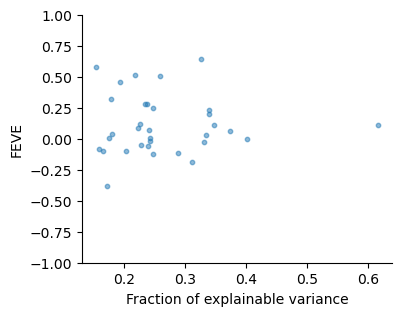

In [ ]:
idx = np.where(fev_all[ineur]>0.15)[0]
fig, ax = plt.subplots(figsize=(4,4))
plt.scatter(fev_all[ineur[idx]], varexp_ratio[idx], s=10, alpha=0.5)
plt.xlabel('Fraction of explainable variance')
plt.ylabel('FEVE')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylim([-1, 1])
ax.set_aspect(0.8/ax.get_data_ratio(), adjustable='box')

In [ ]:
if not os.path.exists(model_path):
    torch.save(best_state_dict, model_path)
    print('saved model', model_path)
model.load_state_dict(torch.load(model_path))
print('loaded model', model_path)

saved model ../weights/sc_2layer_fev-1_16_320_clamp_sensorium_depthsep_pool.pt
loaded model ../weights/sc_2layer_fev-1_16_320_clamp_sensorium_depthsep_pool.pt


# visualize weights

In [ ]:
conv1_W = model.core.features.layer0.conv.weight.detach().cpu().numpy()
print(conv1_W.shape)
conv1_W = conv1_W.squeeze()
print(conv1_W.shape)

conv1_W_ratio = np.zeros(len(conv1_W))
for i in range(len(conv1_W)):
    iW = conv1_W[i]
    conv1_W_ratio[i] = iW[iW>0].sum() / iW[iW<0].sum()

(16, 1, 25, 25)
(16, 25, 25)


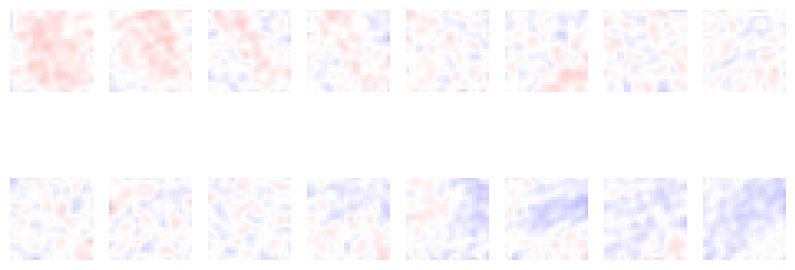

In [ ]:
isort = np.argsort(conv1_W_ratio)
# visualize conv1 kernels
plt.figure(figsize=(10, 4))
for i in range(16):
    plt.subplot(2, 8, i+1)
    im = conv1_W[isort[i]]
    #  gausian filter to visualize the kernel
    from scipy.ndimage import gaussian_filter
    im = gaussian_filter(im, 1)
    plt.imshow(im, cmap='bwr', vmin=-0.1, vmax=0.1)
    plt.axis('off')

In [ ]:
Wc = model.readout.Wc.detach().cpu().numpy().squeeze()
print(Wc.shape, Wc.min(), Wc.max())

(107, 192) -0.10619184 0.04666741


In [ ]:
np.random.seed(0)
isort_neurons = np.argsort(fev_all)[::-1]
ineurons = isort_neurons

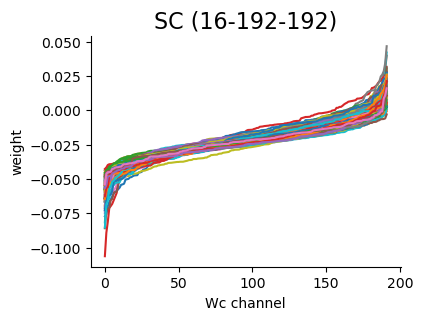

In [ ]:
plt.figure(figsize=(4,3))
Wc_tmp = Wc[ineurons]
for i in range(Wc_tmp.shape[0]):
    plt.plot(np.sort(Wc_tmp[i]))
plt.xlabel('Wc channel')
plt.ylabel('weight')
plt.title(f'SC (16-192-192)', fontsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [ ]:
# the spatial conv
conv2_W = model.core.features.layer1.ds_conv.spatial_conv.weight.detach().cpu().numpy()
print(conv2_W.shape)
conv2_W = conv2_W.squeeze()
print(conv2_W.shape)

(192, 1, 9, 9)
(192, 9, 9)


IndexError: index 192 is out of bounds for axis 0 with size 192

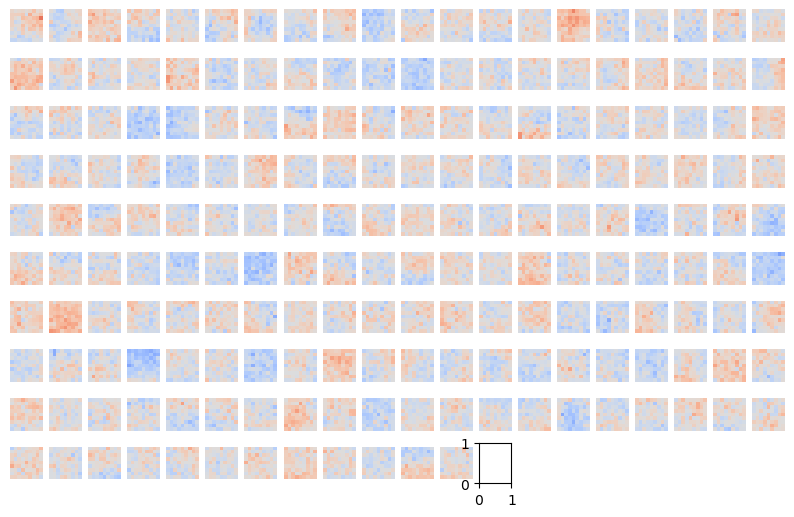

In [ ]:
# visualize conv2 kernels
plt.figure(figsize=(10, 10))
for i in range(320):
    plt.subplot(16, 20, i+1)
    plt.imshow(conv2_W[i], cmap='coolwarm', vmin=-0.1, vmax=0.1)
    plt.axis('off')

In [ ]:
# # change model Wx and Wy
Wx = model.readout.Wx.detach().cpu().numpy()
Wy = model.readout.Wy.detach().cpu().numpy()
Wc = model.readout.Wc.detach().cpu().numpy()
# outer product of Wx and Wy
Wxy = np.einsum('icj,ick->ijk', Wy, Wx)
print(Wxy.shape)

(107, 33, 38)


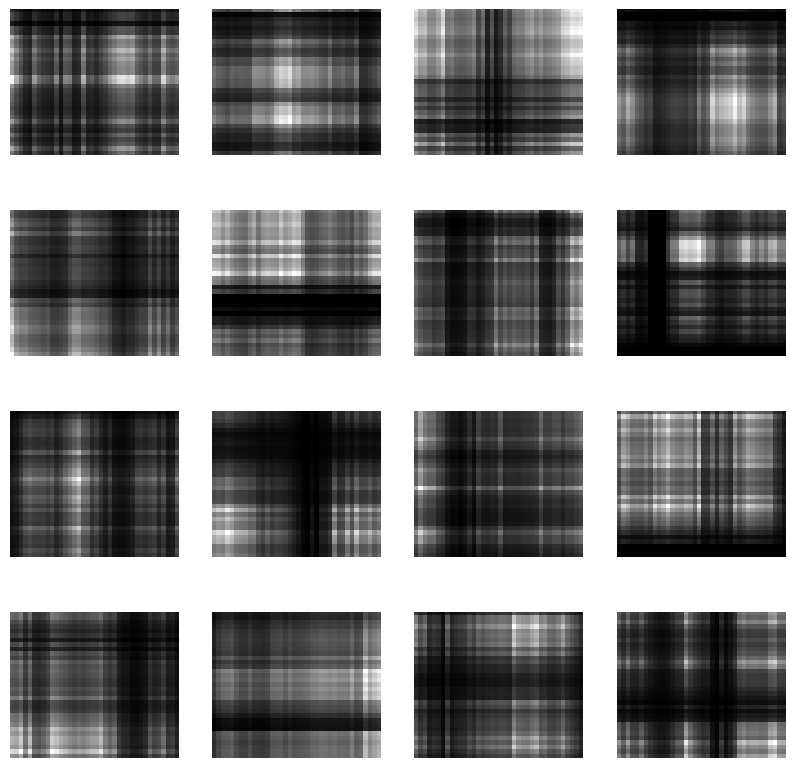

In [ ]:
np.random.seed(42)
ineurons = np.random.choice(len(Wxy), 16, replace=False)
fig, ax = plt.subplots(4, 4, figsize=(10, 10))
for i, ineuron in enumerate(ineurons):
    ax[i//4, i%4].imshow(Wxy[ineuron], cmap='gray')
    ax[i//4, i%4].axis('off')
plt.show()

# power law

1.0543071165987108


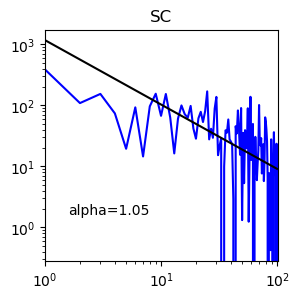

In [ ]:
from approxineuro.data_utils import get_powerlaw, cvPCA
ss = cvPCA(spks_test_rep.cpu().numpy())
xend = 100
plt.figure(figsize=(3,3))
alpha, ypred = get_powerlaw(ss, np.arange(10, xend))
print(alpha)
plt.loglog(np.arange(1,xend+1), ss[:xend], color='blue')
plt.loglog(np.arange(1,xend+1), ypred[:xend], label=f'alpha={alpha:.2f}', color='k')
plt.xlim([1, xend+1])
# put text on the plot
plt.text(0.1, 0.2, f'alpha={alpha:.2f}', transform=plt.gca().transAxes)
plt.title(f'SC')
ss_pred_test = ss.copy()
alpha_pred_test = alpha.copy()

# FEVE change with nlayers

In [ ]:
model.device

device(type='cuda')

In [ ]:
nlayers = 2
nconv1 = 192
nconv2 = 192

feve_all_layers = []
cc_all_layers = []
img_test = img_test.to(device)
for nlayers in range(1, 5):
    model, in_channels = build_model(nlayers, nconv1, nconv2, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes, 
                        depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization)

    # weight_path = '/home/carsen/dm11/Farah/EncodingModel'
    weight_path = '../weights/old'
    model_path = create_model_name(weight_path, in_channels, fev_threshold, highres=highres, multikernel=multikernel, multikernel_sizes=multikernel_sizes,
                                    depth_separable=depth_separable, pool=pool, clamp=clamp, use_sensorium_normalization=use_sensorium_normalization, gabor=gabor,
                                    rank=1, orth_reg=orth_reg, highvar=highvar, use_30k=use_30k, l1_readout=0.0)
    print(model_path)

    model.load_state_dict(torch.load(model_path))
    model.to(device)

    varexp_all = np.zeros((2, len(ineur)))
    cc_all = np.zeros((2, len(ineur)))
    model.eval()
    for i in range(2):
        spks_test = spks_test_rep[i].T
        test_loss, varexp_full, cc_full, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test)
        varexp_all[i] = varexp_full
        cc_all[i] = cc_full
    varexp_ratio = varexp_all.mean(axis=0) / fev_all[ineur]
    # test_loss, varexp_full, cc_all, test_vmax, spks_pred_test = encoder.test_epoch(model, img_test, spks_test_rep.mean(0).T)
    idx = np.where(fev_all[ineur]>0.)[0]
    print('varexp ratio of neurons with fev>0:', varexp_ratio[idx].mean(), cc_all[:, ineur[idx]].mean())
    idx = np.where(fev_all[ineur]>0.15)[0]
    print('varexp ratio of neurons with fev>0.15:', varexp_ratio[idx].mean(), cc_all[:, ineur[idx]].mean())
    feve_all_layers.append(varexp_ratio[idx].mean())
    cc_all_layers.append(cc_all[:, idx].mean())

input shape of readout:  (192, 33, 38)
../weights/old/sc_1layer_fev-1_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: -0.12364985934697287 0.05719755283774784
varexp ratio of neurons with fev>0.15: -0.0018276179144549396 0.08224935519198577
input shape of readout:  (192, 33, 38)
../weights/old/sc_2layer_fev-1_192_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: 0.055485489763387776 0.1121222730250268
varexp ratio of neurons with fev>0.15: 0.11041315991338531 0.16196130763317784
input shape of readout:  (192, 33, 38)
../weights/old/sc_3layer_fev-1_192_192_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: 0.0938626605477265 0.11760186154023335
varexp ratio of neurons with fev>0.15: 0.12746203278758805 0.17313219378279013
input shape of readout:  (192, 33, 38)
../weights/old/sc_4layer_fev-1_192_192_192_192_clamp_sensorium_depthsep_pool.pt
varexp ratio of neurons with fev>0: 0.08650004507831226 0.11802702480389808
vare

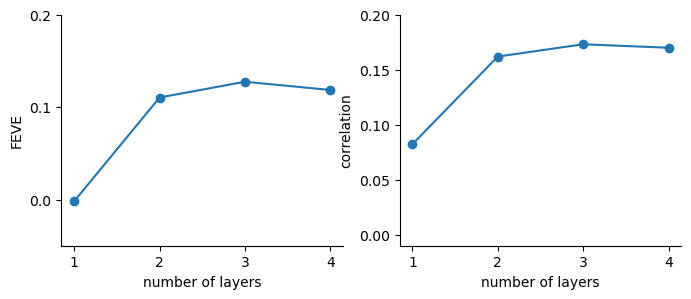

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].plot(np.arange(1, 5), feve_all_layers, marker='o')
ax[0].set_xlabel('number of layers')
ax[0].set_ylabel('FEVE')
ax[0].set_ylim(-0.05, 0.2)
ax[0].set_yticks([0, 0.1, 0.2])
ax[1].plot(np.arange(1, 5), cc_all_layers, marker='o')
ax[1].set_xlabel('number of layers')
ax[1].set_ylabel('correlation')
ax[1].set_ylim(-0.01, 0.2)
ax[1].set_yticks([0, 0.05, 0.1, 0.15, 0.2])
# tight layout
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

In [ ]:
len(idx)

50

# LN model

In [ ]:
img_downsample = 6
img_train, img_val, img_test, spks_train, spks_val, spks_test_rep, fev_all = load_sc_data(img_downsample = img_downsample,
                 use_sensorium_normalization = False,
                 use_zscore_normalization = True,
                 data_path = 'data/sc_processed_data.npz')

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test_rep.shape, spks_test_rep.min(), spks_test_rep.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

(1020, 66, 77) (254, 66, 77) (136, 66, 77)
(107, 1020) (107, 254) (2, 107, 136)
(107,)
downsample images:
train images: (1020, 11, 12)
val images: (254, 11, 12)
test images: (136, 11, 12)
spks_train:  (107, 1020) -0.6189248 19.500912
spks_val:  (107, 254) -0.6189248 22.76846
spks_test:  (2, 107, 136) -0.6189248 18.038963
img_train:  (1020, 11, 12) -2.1710794 2.1371822
img_val:  (254, 11, 12) -2.1710794 2.1371822
img_test:  (136, 11, 12) -2.1710794 2.1371822


In [ ]:
def ridge_model(img_train, img_val, img_test, spks_train, spks_val, spks_test, alpha=1.0, return_model=False):
    from sklearn.linear_model import Ridge
    clf = Ridge(alpha=alpha, fit_intercept=True)
    clf.fit(img_train.squeeze().reshape(img_train.shape[0], -1), spks_train.T)
    spks_pred_train = clf.predict(img_train.squeeze().reshape(img_train.shape[0], -1)).T
    spks_pred_val = clf.predict(img_val.squeeze().reshape(img_val.shape[0], -1)).T
    spks_pred_test = clf.predict(img_test.squeeze().reshape(img_test.shape[0], -1)).T

    # varexp
    varexp_train = 1 - ((spks_train - spks_pred_train)**2).sum(axis=1) / ((spks_train - spks_train.mean(axis=1)[:, None])**2).sum(axis=1)
    varexp_val = 1 - ((spks_val - spks_pred_val)**2).sum(axis=1) / ((spks_val - spks_val.mean(axis=1)[:, None])**2).sum(axis=1)
    varexp_test = 1 - ((spks_test - spks_pred_test)**2).sum(axis=1) / ((spks_test - spks_test.mean(axis=1)[:, None])**2).sum(axis=1)
    # print(varexp_train.mean(), varexp_val.mean(), varexp_test.mean())

    # correlation
    NN = spks_train.shape[0]
    cc_test = np.zeros(NN)  
    cc_val = np.zeros(NN)
    cc_train = np.zeros(NN)
    for i in range(NN):
        cc_test[i] = np.corrcoef(spks_test[i], spks_pred_test[i])[0,1]
        cc_val[i] = np.corrcoef(spks_val[i], spks_pred_val[i])[0,1]
        cc_train[i] = np.corrcoef(spks_train[i], spks_pred_train[i])[0,1]
    # print(cc_train.mean(), cc_val.mean(), cc_test.mean())
    if return_model:
        return varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test, clf
    return varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test

fev_threshold = 0
ineur = np.where(fev_all > fev_threshold)[0]
print(f'selecting {len(ineur)} neurons with fev > {fev_threshold}') 
alpha_list = np.logspace(-3, 6, 20)
res = []
for alpha in alpha_list:
    varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test = ridge_model(img_train, img_val, img_test, spks_train, spks_val, spks_test_rep[0], alpha=alpha)
    # varexp_train = varexp_train / fev_all
    # varexp_val = varexp_val / fev_all
    # varexp_test = varexp_test / fev_all
    res.append([varexp_train[ineur].mean(), varexp_val[ineur].mean(), varexp_test[ineur].mean(), cc_train[ineur].mean(), cc_val[ineur].mean(), cc_test[ineur].mean()])

selecting 78 neurons with fev > 0


Text(0.5, 0.98, 'Ridge regression (zscore spks), downsample=6')

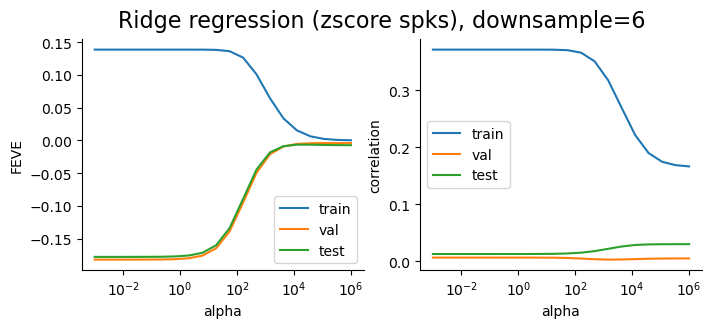

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
train_res = np.array(res)[:, 0]
val_res = np.array(res)[:, 1]
test_res = np.array(res)[:, 2]
train_cc = np.array(res)[:, 3]
val_cc = np.array(res)[:, 4]
test_cc = np.array(res)[:, 5]

ax[0].plot(alpha_list, train_res, label='train')
ax[0].plot(alpha_list, val_res, label='val')
ax[0].plot(alpha_list, test_res, label='test')
ax[0].set_xscale('log')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('FEVE')
ax[0].legend()

ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].plot(alpha_list, train_cc, label='train')
ax[1].plot(alpha_list, val_cc, label='val')
ax[1].plot(alpha_list, test_cc, label='test')

ax[1].set_xscale('log')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('correlation')
ax[1].legend()

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# set title of the figure
fig.suptitle(f'Ridge regression (zscore spks), downsample={img_downsample}', fontsize=16)

In [ ]:
varexp_train, varexp_val, varexp_test, cc_train, cc_val, cc_test, model = ridge_model(img_train, img_val, img_test, spks_train, spks_val, spks_test_rep[0], alpha=1000, return_model=True)
# varexp_train = varexp_train / fev_all
# varexp_val = varexp_val / fev_all
# varexp_test = varexp_test / fev_all
print(varexp_train[ineur].mean(), varexp_val[ineur].mean(), varexp_test[ineur].mean())
print(cc_train[ineur].mean(), cc_val[ineur].mean(), cc_test[ineur].mean())

Ly, Lx = img_train.shape[-2:]
W = model.coef_
W = W.reshape(W.shape[0], Ly, Lx)
print(W.shape)

0.07674837 -0.028211266 -0.024539594
0.3308466278275655 0.0028153531864969807 0.020248767021893373
(107, 11, 12)


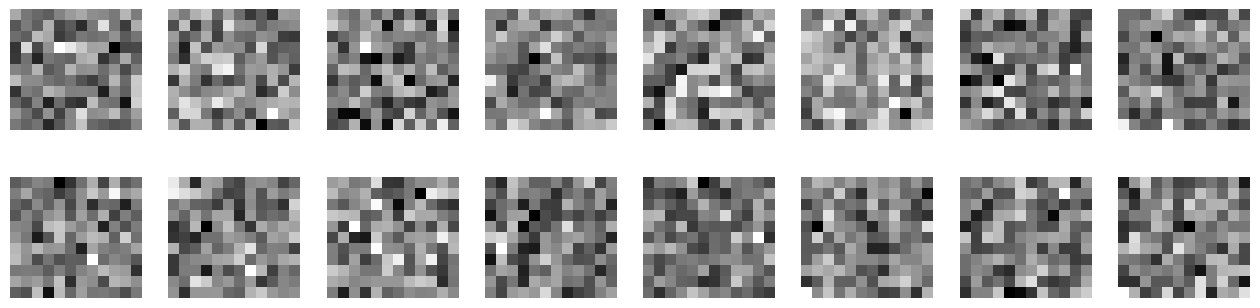

In [ ]:
n_weight_show = 16
idx_show = np.argsort(cc_test)[::-1][:n_weight_show]
nrow = 2
ncol = n_weight_show // nrow
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol*2, nrow*2))
for i in range(n_weight_show):
    # smooth the kernel
    from scipy.ndimage import gaussian_filter
    # wshow = gaussian_filter(W[idx_show[i]], 2)
    # ax[i//ncol, i%ncol].imshow(wshow, cmap='bwr', vmin=-0.01, vmax=0.01)
    wshow = W[idx_show[i]]
    ax[i//ncol, i%ncol].imshow(wshow, cmap='gray')
    ax[i//ncol, i%ncol].axis('off')

# LN model with poisson loss

In [ ]:
img_downsample = 2
img_train, img_val, img_test, spks_train, spks_val, spks_test_rep, fev_all = load_sc_data(img_downsample = img_downsample,
                 use_sensorium_normalization = True,
                 use_zscore_normalization = False,
                 data_path = 'data/sc_processed_data.npz')

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test_rep.shape, spks_test_rep.min(), spks_test_rep.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

(1020, 66, 77) (254, 66, 77) (136, 66, 77)
(107, 1020) (107, 254) (2, 107, 136)
(107,)
downsample images:
train images: (1020, 33, 38)
val images: (254, 33, 38)
test images: (136, 33, 38)
spks_train:  (107, 1020) 0.0 19.869833
spks_val:  (107, 254) 0.0 23.20108
spks_test:  (2, 107, 136) 0.0 18.47648
img_train:  (1020, 33, 38) -2.170586 2.1355014
img_val:  (254, 33, 38) -2.170586 2.1355014
img_test:  (136, 33, 38) -2.170586 2.1355014


In [ ]:
fev_threshold = -1
ineur = np.where(fev_all > fev_threshold)[0]
print(f'selecting {len(ineur)} neurons with fev > {fev_threshold}') 

spks_train = torch.from_numpy(spks_train[ineur].T)
spks_val = torch.from_numpy(spks_val[ineur].T)
spks_test_rep = torch.from_numpy(spks_test_rep[:, ineur])    
spks_test = spks_test_rep[0].T

print(spks_train.shape, spks_val.shape, spks_test.shape)

img_train = torch.from_numpy(img_train).to(device).unsqueeze(1)
img_val = torch.from_numpy(img_val).to(device).unsqueeze(1)
img_test = torch.from_numpy(img_test).to(device).unsqueeze(1)

print(img_train.shape, img_val.shape, img_test.shape)

print('spks_train: ', spks_train.shape, spks_train.min(), spks_train.max())
print('spks_val: ', spks_val.shape, spks_val.min(), spks_val.max())
print('spks_test: ', spks_test.shape, spks_test.min(), spks_test.max())
print('img_train: ', img_train.shape, img_train.min(), img_train.max())
print('img_val: ', img_val.shape, img_val.min(), img_val.max())
print('img_test: ', img_test.shape, img_test.min(), img_test.max())

input_Ly, input_Lx = img_train.shape[-2:]

selecting 107 neurons with fev > -1
torch.Size([1020, 107]) torch.Size([254, 107]) torch.Size([136, 107])
torch.Size([1020, 1, 33, 38]) torch.Size([254, 1, 33, 38]) torch.Size([136, 1, 33, 38])
spks_train:  torch.Size([1020, 107]) tensor(0.) tensor(19.8698)
spks_val:  torch.Size([254, 107]) tensor(0.) tensor(23.2011)
spks_test:  torch.Size([136, 107]) tensor(0.) tensor(18.4765)
img_train:  torch.Size([1020, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
img_val:  torch.Size([254, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)
img_test:  torch.Size([136, 1, 33, 38]) tensor(-2.1706) tensor(2.1355)


In [ ]:
from torch import nn
NN = spks_train.shape[1]
Ly, Lx = img_test.shape[-2:]

# train a linear-nonlinear model use torch
# Y = elu(W * X + b)
# W: NN x Ly*Lx 
# X: Ly*Lx 
# Y: NN 
# b: NN

# device = torch.device('cpu')
W = 0.01 * torch.randn(NN, Ly*Lx, device=device, requires_grad=True)
b = 0.01 * torch.randn(NN, device=device, requires_grad=True)
W = nn.Parameter(W)
b = nn.Parameter(b)
optimizer = torch.optim.Adam([W, b], lr=1e-3)


n_epochs = 100
for epoch in range(n_epochs):
    optimizer.zero_grad()
    Y = torch.nn.functional.elu((W @ img_train.view(-1, Ly*Lx).T).T + b) 
    # poisson loss
    loss = (Y - spks_train * torch.log(Y)).sum(axis=0).mean()
    # mse loss
    # loss = ((Y - spks_train)**2).mean(axis=0).mean()
    # l2 loss
    l2_loss = (W**2).sum() + (b**2).sum()
    loss += 0.1*l2_loss
    loss.backward()
    optimizer.step()
    if epoch%10==0:
        print(f'epoch {epoch}, loss = {loss.item(), l2_loss.item()}')
        # calculate variance explained
        Y_val = torch.nn.functional.elu((W @ img_val.view(-1, Ly*Lx).T).T + b) + 1
        varexp = 1 - (Y_val - spks_val).var(axis=0) / spks_val.var(axis=0)
        print(f'varexp = {varexp.mean()}')

epoch 0, loss = (nan, 13.407368659973145)
varexp = -0.1596498042345047
epoch 10, loss = (nan, 15.848854064941406)
varexp = -0.7585952877998352
epoch 20, loss = (nan, 17.805707931518555)
varexp = -1.0227099657058716
epoch 30, loss = (nan, 18.97649383544922)
varexp = -1.0769425630569458
epoch 40, loss = (nan, 19.679637908935547)
varexp = -1.0523521900177002
epoch 50, loss = (nan, 20.204566955566406)
varexp = -1.018996000289917
epoch 60, loss = (nan, 20.68100357055664)
varexp = -0.9900180697441101
epoch 70, loss = (nan, 21.12504005432129)
varexp = -0.9583154320716858
epoch 80, loss = (nan, 21.57845115661621)
varexp = -0.9375667572021484
epoch 90, loss = (nan, 22.063480377197266)
varexp = -0.9163715839385986


# gabor model